<a href="https://colab.research.google.com/github/annalocvf/Estudo-GLP-TCC-IC-UFOP/blob/main/Capitulo1/capitulo1_figura5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
import zipfile

# Install gdown if not already installed
!pip install -U gdown

# Google Drive file ID from the URL
file_id = '1flfD9yVrsSu7gRhZru_6cHcATbbvREAh'
output_filename = 'downloaded_archive.zip'

print(f'Downloading file with ID: {file_id}...')
!gdown --id {file_id} -O {output_filename}
print(f'File downloaded as {output_filename}')

# Create a directory to extract files into
extraction_path = 'extracted_files'
os.makedirs(extraction_path, exist_ok=True)

# Extract the contents of the zip file
if os.path.exists(output_filename):
    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f'All files extracted to: {extraction_path}')

    # List contents of the extracted directory
    print(f'Contents of {extraction_path}:')
    for root, dirs, files in os.walk(extraction_path):
        for name in files:
            print(os.path.join(root, name))
        for name in dirs:
            print(os.path.join(root, name) + '/')
else:
    print(f'Error: {output_filename} not found. Download might have failed.')

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1flfD9yVrsSu7gRhZru_6cHcATbbvREAh
From (redirected): https://drive.google.com/uc?id=1flfD9yVrsSu7gRhZru_6cHcATbbvREAh&confirm=t&uuid=a9f687a8-cec4-47db-831d-006fa5f67841
To: /content/downloaded_archive.zip
100% 217M/217M [00:01<00:00, 134MB/s]
File downloaded as downloaded_archive.zip
All files extracted to: extracted_files
Contents of extracted_files:
extracted_files/glp-2020-02.csv
extracted_files/glp-2018-02.csv
extracted_files/glp-2023-01.csv
extracted_files/glp-2016-01.csv
extracted_files/glp-2017-02.csv
extracted_files/glp-2023-02.csv
extracted_files/glp-2021-02.csv
extracted_files/glp-2010-01.csv
extracted_files/glp-2014-01.csv
extracted_files/glp-2015-02.csv
extracted_files/glp-2014-02.csv
extracted

In [7]:
import pandas as pd
import os

extraction_path = 'extracted_files'
all_files = [os.path.join(extraction_path, f) for f in os.listdir(extraction_path) if f.endswith('.csv')]

li = []

for filename in all_files:
    try:
        # Specify separator as ';' and handle bad lines by skipping them
        df_temp = pd.read_csv(filename, sep=';', on_bad_lines='skip')
        li.append(df_temp)
    except Exception as e:
        print(f"Error reading {filename}: {e}")

if li:
    full_df = pd.concat(li, axis=0, ignore_index=True)
    print("Combined DataFrame info (full_df):")
    full_df.info()
    print("\nFirst 5 rows of full_df:")
    display(full_df.head())
else:
    print("No CSV files were successfully loaded.")

/tmp/ipykernel_5877/3168787333.py:12: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(filename, sep=';', on_bad_lines='skip')


Combined DataFrame info (full_df):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4325947 entries, 0 to 4325946
Data columns (total 16 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   Regiao - Sigla     object
 1   Estado - Sigla     object
 2   Municipio          object
 3   Revenda            object
 4   CNPJ da Revenda    object
 5   Nome da Rua        object
 6   Numero Rua         object
 7   Complemento        object
 8   Bairro             object
 9   Cep                object
 10  Produto            object
 11  Data da Coleta     object
 12  Valor de Venda     object
 13  Valor de Compra    object
 14  Unidade de Medida  object
 15  Bandeira           object
dtypes: object(16)
memory usage: 528.1+ MB

First 5 rows of full_df:


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,S,RS,SANTA MARIA,SANTA LUCIA COMERCIO E PAVIMENTACOES LTDA,87.305.868/0001-88,RODOVIA RS 509,1200,KM 03,JOÃO GOULART,97095-000,GLP,02/07/2020,70,NaN,R$ / 13 kg,ULTRAGAZ
1,N,AM,ITACOATIARA,MARCOS ANTONIO DA SILVA CABRAL,03.019.535/0005-26,RUA BEIJA-FLOR,2501,NaN,SÃO FRANCISCO,69100-000,GLP,01/07/2020,87,NaN,R$ / 13 kg,FOGAS
2,NE,BA,ILHEUS,COMERCIAL SAVOIA LTDA,02.366.787/0001-35,AVENIDA RAYMUNDO SA BARRETO,S/N,LOTES 26 27 E 28,JARDIM SAVOIA,45658-250,GLP,01/07/2020,85,68,R$ / 13 kg,BAHIANA
3,CO,DF,BRASILIA,AUTO SHOPPING QL 06 COMERCIO DE DERIV DE PETRO...,00.647.440/0001-35,QUADRA SHIS QI 05/QL 06 LOTE 01 PAC 01,S/N,NaN,SETOR DE HABITACOES INDIVIDUAIS SUL,71620-060,GLP,01/07/2020,90,"63,73",R$ / 13 kg,LIQUIGÁS
4,CO,GO,ANAPOLIS,LESSA GUIMARAES DERIVADOS DE PETROLEO LTDA,04.792.468/0001-17,AVENIDA FERNANDO COSTA,828,NaN,VILA JAIARA,75064-780,GLP,01/07/2020,72,NaN,R$ / 13 kg,LIQUIGÁS


In [8]:
import numpy as np

# Convert 'Data da Coleta' to datetime objects, coercing errors to NaT
full_df['Data da Coleta'] = pd.to_datetime(full_df['Data da Coleta'], errors='coerce')

# Extract the year
full_df['Year'] = full_df['Data da Coleta'].dt.year

# Convert the extracted year column to a numeric type (integer) and fill any potential missing values with 0
full_df['Year'] = full_df['Year'].fillna(0).astype(int)

# Create a new DataFrame named df_yearly_unique by selecting the specified columns
df_yearly_unique = full_df[['Estado - Sigla', 'CNPJ da Revenda', 'Year']].copy()

# Remove duplicate rows from df_yearly_unique based on these three columns
df_yearly_unique.drop_duplicates(inplace=True)

print("First 5 rows of df_yearly_unique:")
display(df_yearly_unique.head())

print("\nInformation about df_yearly_unique:")
df_yearly_unique.info()

First 5 rows of df_yearly_unique:


,Estado - Sigla,CNPJ da Revenda,Year
0,RS,87.305.868/0001-88,2020
1,AM,03.019.535/0005-26,2020
2,BA,02.366.787/0001-35,2020
3,DF,00.647.440/0001-35,2020
4,GO,04.792.468/0001-17,2020



Information about df_yearly_unique:
<class 'pandas.core.frame.DataFrame'>
Index: 224973 entries, 0 to 4313211
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Estado - Sigla   224973 non-null  object
 1   CNPJ da Revenda  224973 non-null  object
 2   Year             224973 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 6.9+ MB


In [9]:
unique_resellers_per_state_year = df_yearly_unique.groupby(['Estado - Sigla', 'Year'])['CNPJ da Revenda'].count().reset_index()
unique_resellers_per_state_year.rename(columns={'CNPJ da Revenda': 'Unique Reseller Count', 'Estado - Sigla': 'State'}, inplace=True)

# Filter for years 2018-2025
unique_resellers_per_state_year = unique_resellers_per_state_year[(unique_resellers_per_state_year['Year'] >= 2018) & (unique_resellers_per_state_year['Year'] <= 2025)]

print("First 5 rows of unique_resellers_per_state_year:")
display(unique_resellers_per_state_year.head())

print("\nInformation about unique_resellers_per_state_year:")
unique_resellers_per_state_year.info()

First 5 rows of unique_resellers_per_state_year:


,State,Year,Unique Reseller Count
9,AC,2018,119
10,AC,2019,94
11,AC,2020,94
12,AC,2021,81
13,AC,2022,63



Information about unique_resellers_per_state_year:
<class 'pandas.core.frame.DataFrame'>
Index: 216 entries, 9 to 458
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   State                  216 non-null    object
 1   Year                   216 non-null    int64 
 2   Unique Reseller Count  216 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 6.8+ KB


In [10]:
state_to_region_mapping = {
    'AC': 'Norte',
    'AL': 'Nordeste',
    'AM': 'Norte',
    'AP': 'Norte',
    'BA': 'Nordeste',
    'CE': 'Nordeste',
    'DF': 'Centro-Oeste',
    'ES': 'Sudeste',
    'GO': 'Centro-Oeste',
    'MA': 'Nordeste',
    'MG': 'Sudeste',
    'MS': 'Centro-Oeste',
    'MT': 'Centro-Oeste',
    'PA': 'Norte',
    'PB': 'Nordeste',
    'PE': 'Nordeste',
    'PI': 'Nordeste',
    'PR': 'Sul',
    'RJ': 'Sudeste',
    'RN': 'Nordeste',
    'RO': 'Norte',
    'RR': 'Norte',
    'RS': 'Sul',
    'SC': 'Sul',
    'SE': 'Nordeste',
    'SP': 'Sudeste',
    'TO': 'Norte'
}

unique_resellers_per_state_year['Region'] = unique_resellers_per_state_year['State'].map(state_to_region_mapping)

print("First 5 rows of unique_resellers_per_state_year with 'Region' column:")
display(unique_resellers_per_state_year.head())
print("\nInformation about unique_resellers_per_state_year with 'Region' column:")
unique_resellers_per_state_year.info()

First 5 rows of unique_resellers_per_state_year with 'Region' column:


,State,Year,Unique Reseller Count,Region
9,AC,2018,119,Norte
10,AC,2019,94,Norte
11,AC,2020,94,Norte
12,AC,2021,81,Norte
13,AC,2022,63,Norte



Information about unique_resellers_per_state_year with 'Region' column:
<class 'pandas.core.frame.DataFrame'>
Index: 216 entries, 9 to 458
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   State                  216 non-null    object
 1   Year                   216 non-null    int64 
 2   Unique Reseller Count  216 non-null    int64 
 3   Region                 216 non-null    object
dtypes: int64(2), object(2)
memory usage: 8.4+ KB


In [11]:
import pandas as pd

# Create a list region_order with the specified order
region_order = ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']

# Convert the 'Region' column to a categorical data type
# using pd.Categorical with the region_order and set ordered=True
unique_resellers_per_state_year['Region'] = pd.Categorical(
    unique_resellers_per_state_year['Region'],
    categories=region_order,
    ordered=True
)

# Group the DataFrame by 'Year' and 'Region' and calculate the sum of 'Unique Reseller Count'
# Store the result in a new DataFrame called resellers_by_region_year
resellers_by_region_year = unique_resellers_per_state_year.groupby(['Year', 'Region'], observed=False)['Unique Reseller Count'].sum().reset_index()

print("Head of resellers_by_region_year:")
display(resellers_by_region_year.head())

print("\nInfo of resellers_by_region_year:")
resellers_by_region_year.info()

Head of resellers_by_region_year:


,Year,Region,Unique Reseller Count
0,2018,Centro-Oeste,2009
1,2018,Nordeste,2408
2,2018,Norte,1469
3,2018,Sudeste,4965
4,2018,Sul,1886



Info of resellers_by_region_year:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Year                   40 non-null     int64   
 1   Region                 40 non-null     category
 2   Unique Reseller Count  40 non-null     int64   
dtypes: category(1), int64(2)
memory usage: 1.0 KB


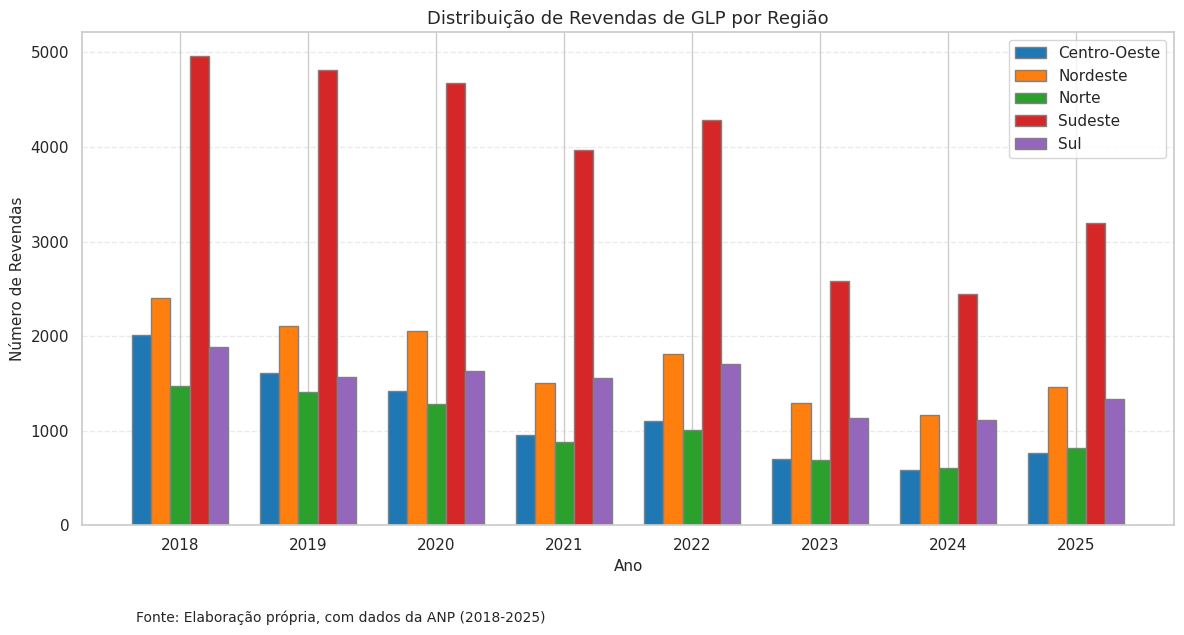

In [12]:
import matplotlib.pyplot as plt

# Define a list of colors as specified
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Get the unique years from the resellers_by_region_year DataFrame
years = sorted(resellers_by_region_year['Year'].unique())

# Set the width for the bars and calculate positions for each group of bars for every year
bar_width = 0.15
r_years = range(len(years))

plt.figure(figsize=(12, 6))

# Get unique regions in the specified order (already set as categorical)
regions = resellers_by_region_year['Region'].cat.categories

# Iterate through each region and plot the 'Unique Reseller Count' for each year
for i, region in enumerate(regions):
    # Filter data for the current region
    region_data = resellers_by_region_year[resellers_by_region_year['Region'] == region]

    # Align data with years to ensure all years are present, filling missing with 0 for plotting
    plot_values = [region_data[region_data['Year'] == year]['Unique Reseller Count'].sum() if year in region_data['Year'].values else 0 for year in years]

    # Calculate bar positions for the current region
    bars = [x + bar_width * i for x in r_years]
    plt.bar(bars, plot_values, color=colors[i], width=bar_width, edgecolor='grey', label=region)

# Set the x-axis tick labels to be the years
plt.xlabel('Ano', fontsize=11)
plt.ylabel('Número de Revendas', fontsize=11)
plt.title('Distribuição de Revendas de GLP por Região', fontsize=13)
plt.xticks([r + bar_width * (len(regions) - 1) / 2 for r in r_years], years)

# Light horizontal grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add a legend to the plot, positioned in the top-left corner
plt.legend(loc='upper right', frameon=True)

# Add source text below the graph
plt.figtext(
    0.12, -0.05,
    'Fonte: Elaboração própria, com dados da ANP (2018-2025)',
    fontsize=10
)

# Ensure the layout is tight using plt.tight_layout()
plt.tight_layout()

# Display the plot using plt.show()
plt.show()